# 02 · M2 1D CNN, trained with RMSprop and tuned with DE / PSO

**Owner:** Parth Upadhyay  
Scripts: `src/models/m2_cnn1d.py`, `src/search.py`.

In [1]:
# Setup: works locally (run from notebooks/) and on Google Colab.
# On Colab, first clone the team repository and install the requirements:
#   !git clone <repo-url> ecg-arrhythmia && %cd ecg-arrhythmia/notebooks
#   !pip install -q -r ../requirements.txt
import os, sys, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = os.path.abspath('..')
sys.path[:0] = [os.path.join(ROOT, 'src'), os.path.join(ROOT, 'src', 'models')]
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif']})
%matplotlib inline

In [2]:
from m2_cnn1d import build, SPACE, DEFAULT, SEARCH_EPOCHS, SEARCH_N_FRACTION
print("search space:"); [print("  ", k, v) for k, v in SPACE.spec.items()]
print("default config:", DEFAULT)
print("per-candidate budget:", SEARCH_EPOCHS, "epochs on all minority beats +", SEARCH_N_FRACTION, "of N beats")

search space:
   lr ('log', 0.0002, 0.003)
   filters ('choice', [16, 24, 32, 48])
   kernel ('choice', [5, 7, 9, 11, 15])
   blocks ('int', 2, 4)
   dropout ('float', 0.1, 0.5)
   dense ('choice', [32, 64, 128])
default config: {'lr': 0.001, 'filters': 32, 'kernel': 7, 'blocks': 3, 'dropout': 0.3, 'dense': 64}
per-candidate budget: 6 epochs on all minority beats + 0.25 of N beats


## Differential Evolution vs Particle Swarm Optimisation
Both searches use the same box, seed and budget (5 agents × (2 iterations + initial population) = 15 candidate trainings). The objective is 1 − validation macro-F1 over N/S/V/F. DS2 is never used.

DE  best val macro-F1(NSVF) 0.4524  config {'lr': 0.00124, 'filters': 16, 'kernel': 7, 'blocks': 2, 'dropout': 0.1, 'dense': 32}
PSO best val macro-F1(NSVF) 0.4474  config {'lr': 0.00163, 'filters': 24, 'kernel': 15, 'blocks': 4, 'dropout': 0.1377, 'dense': 128}


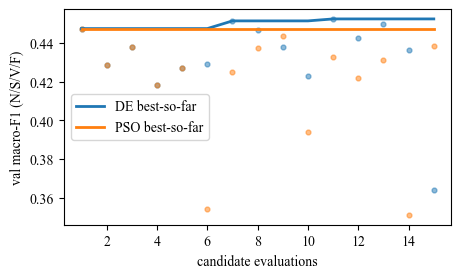

In [3]:
fig, ax = plt.subplots(figsize=(5, 2.8))
searches = {}
for opt in ["de", "pso"]:
    r = json.load(open(os.path.join(ROOT, "results", f"m2_cnn1d_search_{opt}.json"))); searches[opt] = r
    f1 = [1 - e["objective"] for e in r["evaluations"]]
    ax.plot(range(1, len(f1) + 1), np.maximum.accumulate(f1), lw=2, label=f"{opt.upper()} best-so-far")
    ax.scatter(range(1, len(f1) + 1), f1, s=12, alpha=.5)
    print(f"{opt.upper():3s} best val macro-F1(NSVF) {r['best_val_macro_f1_nsvf']:.4f}  config {r['best_config']}")
ax.set_xlabel("candidate evaluations"); ax.set_ylabel("val macro-F1 (N/S/V/F)"); ax.legend(); plt.show()

## Final model: winning configuration retrained on all of DS1-train with 3 seeds

In [4]:
from deep_common import load_data
winner = max(searches.values(), key=lambda r: r["best_val_macro_f1_nsvf"])
CFG = dict(winner["best_config"]); TAG = "m2_cnn1d_tuned"
print("tuned by", winner["optimizer"].upper(), CFG)
build(CFG).summary()

tuned by DE {'lr': 0.00124, 'filters': 16, 'kernel': 7, 'blocks': 2, 'dropout': 0.1, 'dense': 32}


Model: "cnn1d"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ beat (InputLayer)   │ (None, 360, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 360, 16)   │        112 │ beat[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 360, 16)   │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 360, 16)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 180, 16)   │          0 │ re_lu[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 180, 32)   │      3,584 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 180, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 90, 32)    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling1d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr (InputLayer)     │ (None, 4)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 36)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ rr[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        165 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,237 (20.46 KB)

 Trainable params: 5,141 (20.08 KB)

 Non-trainable params: 96 (384.00 B)

In [5]:
# Re-score the saved weights of every seed on DS2 and check they reproduce the
# numbers stored in results/ by the training script.
from deep_common import load_data, load_trained, predict
from evaluate import score
from config import SEEDS, CLASSES
data = load_data()
Xte, Fte, yte = data['test']
rows = []
for seed in SEEDS:
    model = load_trained(build, CFG, TAG, seed)
    m = score(yte, predict(model, Xte, Fte))
    with open(os.path.join(ROOT, 'results', 'runs', f'{TAG}_seed{seed}.json')) as fh:
        saved = json.load(fh)
    rows.append((seed, m['accuracy'], m['macro_f1'], m['macro_f1_nsvf'],
                 abs(m['macro_f1'] - saved['macro_f1']) < 1e-9))
print('seed  accuracy  macro-F1  macro-F1(NSVF)  matches saved')
for r in rows:
    print(f'{r[0]:4d}  {r[1]:.4f}    {r[2]:.4f}    {r[3]:.4f}          {r[4]}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-02 13:58:37.057271: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


seed  accuracy  macro-F1  macro-F1(NSVF)  matches saved
  42  0.8416    0.2933    0.3667          True
  43  0.9406    0.4296    0.5370          True
  44  0.8965    0.3558    0.4448          True


DS2 macro-F1 0.3596 +/- 0.0557 (N/S/V/F: 0.4495 +/- 0.0696)
class   recall           F1
  N    0.929 ± 0.044    0.950 ± 0.018   (n=44228)
  S    0.123 ± 0.095    0.184 ± 0.137   (n=1836)
  V    0.938 ± 0.039    0.647 ± 0.145   (n=3220)
  F    0.027 ± 0.037    0.018 ± 0.022   (n=388)
  Q    0.000 ± 0.000    0.000 ± 0.000   (n=7)


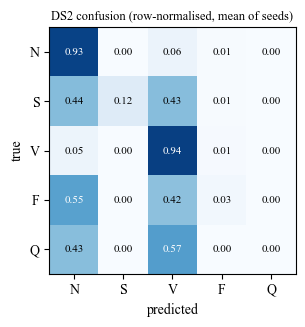

In [6]:
with open(os.path.join(ROOT, 'results', f'{TAG}.json')) as fh:
    agg = json.load(fh)
print(f"DS2 macro-F1 {agg['macro_f1']['mean']:.4f} +/- {agg['macro_f1']['std']:.4f} "
      f"(N/S/V/F: {agg['macro_f1_nsvf']['mean']:.4f} +/- {agg['macro_f1_nsvf']['std']:.4f})")
print('class   recall           F1')
for c in CLASSES:
    r, f = agg['per_class_recall'][c], agg['per_class_f1'][c]
    print(f"  {c}    {r['mean']:.3f} ± {r['std']:.3f}    {f['mean']:.3f} ± {f['std']:.3f}   (n={agg['support'][c]})")
cm = np.array(agg['confusion_matrix_sum']) / len(agg['seeds'])
norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{norm[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if norm[i,j] > .55 else 'black')
ax.set_xticks(range(5), CLASSES); ax.set_yticks(range(5), CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('DS2 confusion (row-normalised, mean of seeds)', fontsize=9)
plt.show()

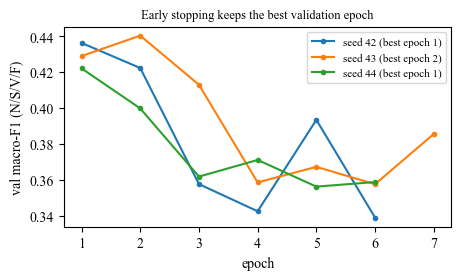

In [7]:
fig, ax = plt.subplots(figsize=(5, 2.6))
for seed in SEEDS:
    with open(os.path.join(ROOT, 'results', 'runs', f'{TAG}_seed{seed}.json')) as fh:
        r = json.load(fh)
    h = r['history']
    ax.plot([e['epoch'] for e in h], [e['val_macro_f1_nsvf'] for e in h], marker='o', ms=3,
            label=f"seed {seed} (best epoch {r['best_epoch']})")
ax.set_xlabel('epoch'); ax.set_ylabel('val macro-F1 (N/S/V/F)'); ax.legend(fontsize=8)
ax.set_title('Early stopping keeps the best validation epoch', fontsize=9)
plt.show()

## Effect of tuning: default vs DE/PSO-tuned CNN on DS2 (mean ± std over 3 seeds)

In [8]:
for tag in ["m2_cnn1d_default", "m2_cnn1d_tuned"]:
    a = json.load(open(os.path.join(ROOT, "results", f"{tag}.json")))
    print(f"{tag:18s} macro-F1 {a['macro_f1']['mean']:.4f} ± {a['macro_f1']['std']:.4f}   N/S/V/F {a['macro_f1_nsvf']['mean']:.4f} ± {a['macro_f1_nsvf']['std']:.4f}")

m2_cnn1d_default   macro-F1 0.3855 ± 0.0483   N/S/V/F 0.4819 ± 0.0604
m2_cnn1d_tuned     macro-F1 0.3596 ± 0.0557   N/S/V/F 0.4495 ± 0.0696


In [9]:
# Full retraining (3 seeds). Takes 30-60 min on a laptop CPU, a few minutes
# on a Colab GPU. Uncomment to reproduce results/m2_cnn1d_tuned.json from scratch.
# !cd .. && python src/models/m2_cnn1d.py --mode final